# 📊 Exploratory Data Analysis: Feature Distributions & Outlier Analysis
**Objective:** Analyze the statistical distributions of cleaned continuous and discrete features, evaluate univariate and bivariate patterns, and perform formal outlier detection using Tukey's Fence method (Interquartile Range - IQR).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# Load cleaned dataset
df = pd.read_csv('../data/interim/ObesityDataSet_cleaned.csv')

print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (2111, 17)


## 1. Distribution of Biometric & Continuous Features

We inspect the probability density and frequency distribution of continuous biometric variables (`Age`, `Height`, `Weight`) using histograms and Kernel Density Estimation (KDE) to assess skewness and multi-modality.

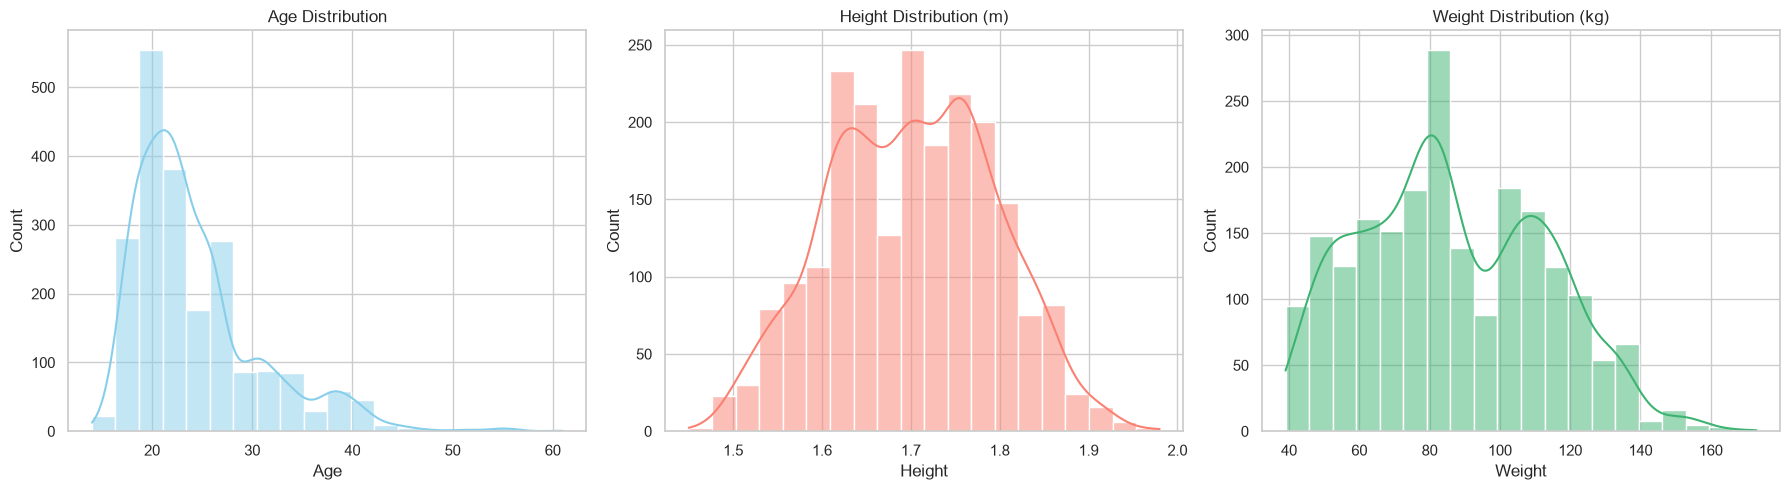

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot distributions for Age, Height, Weight
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Age Distribution')

sns.histplot(df['Height'], kde=True, ax=axes[1], color='salmon', bins=20)
axes[1].set_title('Height Distribution (m)')

sns.histplot(df['Weight'], kde=True, ax=axes[2], color='mediumseagreen', bins=20)
axes[2].set_title('Weight Distribution (kg)')

plt.tight_layout()
plt.savefig('../visuals/plot_distributions_for_age_height_weight.png', dpi=300, bbox_inches='tight')
plt.show()

#### 🚻 Demographic Disaggregation: Height & Weight by Gender

While general continuous distributions provide an initial overview of feature ranges, biometric measurements are fundamentally influenced by biological sex. 

To evaluate whether population sub-clusters exist and to prevent baseline distribution masking, we segment `Weight` and `Height` distributions by `Gender`. This allows us to observe sex-specific central tendencies, variance, and overlap across the sample.

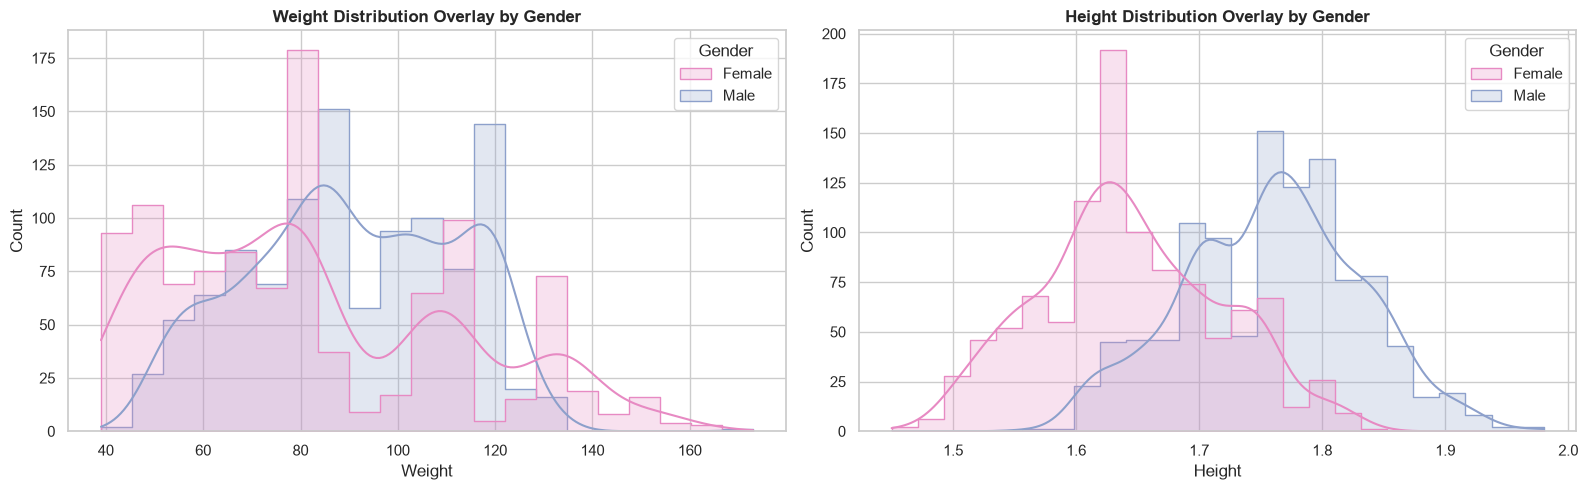

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weight distribution by Gender
sns.histplot(
    data=df, x='Weight', hue='Gender', kde=True, element="step",
    palette={'Female': '#e78ac3', 'Male': '#8da0cb'}, ax=axes[0]
)
axes[0].set_title('Weight Distribution Overlay by Gender', fontsize=12, fontweight='bold')

# Height distribution by Gender
sns.histplot(
    data=df, x='Height', hue='Gender', kde=True, element="step",
    palette={'Female': '#e78ac3', 'Male': '#8da0cb'}, ax=axes[1]
)
axes[1].set_title('Height Distribution Overlay by Gender', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/plot_distributions_for_height_weight_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Key Observations from Gender-Disaggregated Distributions

* **Height Bimodal Shift:** `Height` displays a clear bimodal separation when segmented by `Gender`. Male records exhibit a noticeably higher mean height distribution (~1.75 m) compared to female records (~1.62 m), confirming distinct biological baselines.
* **Weight Variance & Overlay:** `Weight` distributions overlap significantly between sexes, but male profiles show greater variance and a higher upper density bound.
* **Feature Engineering Rationale:** The distinct structural baselines between males and females confirm that keeping `Gender` as an explicit feature—and leveraging compound metrics like Body Mass Index ($\text{BMI} = \frac{\text{Weight}}{\text{Height}^2}$)—will be crucial for downstream model accuracy and fair feature scaling.

## 2. Outlier Detection (Tukey's Rule / IQR Method)

We apply **Tukey's Fences** method to identify statistical anomalies in continuous variables:
* $\text{IQR} = Q_3 - Q_1$
* $\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$
* $\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$

> **Domain Note:** Outliers identified by statistical rules are not automatically removed. In population health datasets, extreme biometric values (e.g., high body weight in severe obesity cases) represent valid biological variability rather than measurement errors.

In [4]:
continuous_cols = ['Age', 'Height', 'Weight']

print("=== TUKEY'S OUTLIER ANALYSIS ===")
for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"\nFeature: {col}")
    print(f"  Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {len(outliers)} ({outlier_pct:.2f}%)")

=== TUKEY'S OUTLIER ANALYSIS ===

Feature: Age
  Q1: 20.00 | Q3: 26.00 | IQR: 6.00
  Bounds: [11.00, 35.00]
  Outliers detected: 160 (7.58%)

Feature: Height
  Q1: 1.63 | Q3: 1.77 | IQR: 0.14
  Bounds: [1.42, 1.98]
  Outliers detected: 0 (0.00%)

Feature: Weight
  Q1: 65.45 | Q3: 107.45 | IQR: 42.00
  Bounds: [2.45, 170.45]
  Outliers detected: 1 (0.05%)


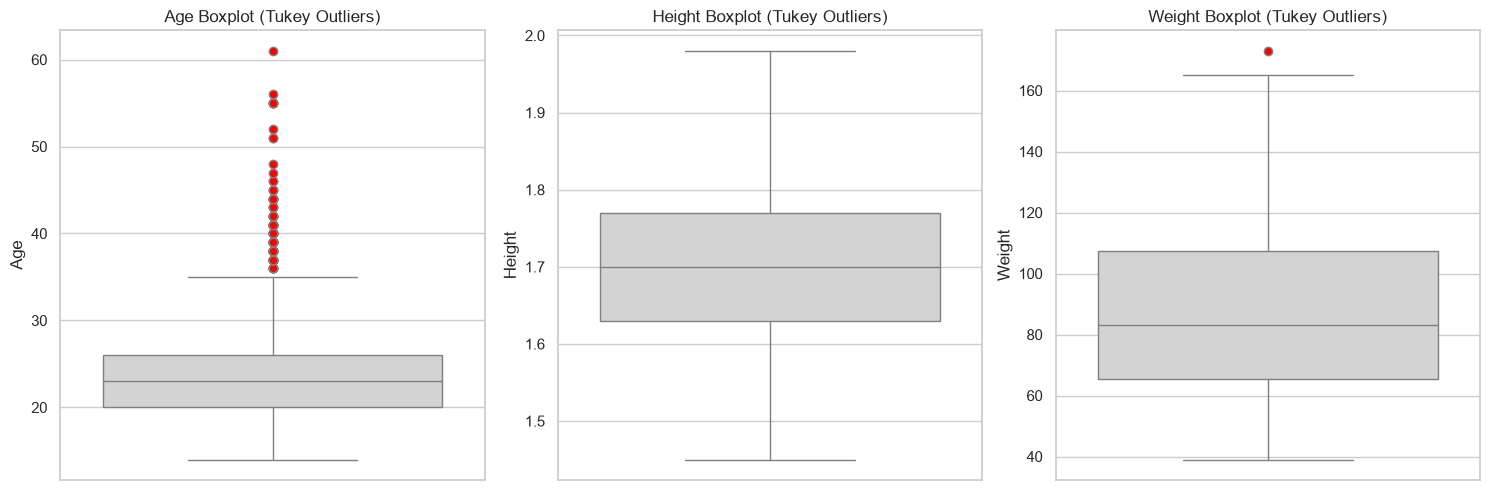

In [5]:
# Visualize Boxplots for Outlier Inspection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgray', flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    axes[i].set_title(f'{col} Boxplot (Tukey Outliers)')

plt.tight_layout()
plt.savefig('../visuals/boxplots_for_outlier_inspection.png', dpi=300, bbox_inches='tight')
plt.show()

#### 🚻 Gender-Disaggregated Outlier Detection (Tukey's Fences)

Applying global statistical outlier bounds across mixed-sex biometric data can create baseline distortion (e.g., flagging tall male profiles or light female profiles as statistical anomalies). 

To ensure demographic accuracy, we apply **Tukey's Fences** ($1.5 \times \text{IQR}$) independently within each gender group (`Male` vs. `Female`) for continuous biometric features (`Age`, `Height`, `Weight`).

=== GENDER-DISAGGREGATED TUKEY OUTLIER ANALYSIS ===

--- Feature: Age ---
[Female] Q1: 20.00 | Q3: 26.00 | IQR: 6.00 | Bounds: [11.00, 35.00] -> Outliers: 96 (9.20%)
[Male] Q1: 20.00 | Q3: 28.00 | IQR: 8.00 | Bounds: [8.00, 40.00] -> Outliers: 22 (2.06%)

--- Feature: Height ---
[Female] Q1: 1.60 | Q3: 1.70 | IQR: 0.10 | Bounds: [1.45, 1.85] -> Outliers: 1 (0.10%)
[Male] Q1: 1.71 | Q3: 1.81 | IQR: 0.10 | Bounds: [1.55, 1.96] -> Outliers: 2 (0.19%)

--- Feature: Weight ---
[Female] Q1: 58.00 | Q3: 105.00 | IQR: 47.00 | Bounds: [-12.50, 175.50] -> Outliers: 0 (0.00%)
[Male] Q1: 75.00 | Q3: 108.45 | IQR: 33.45 | Bounds: [24.82, 158.62] -> Outliers: 1 (0.09%)


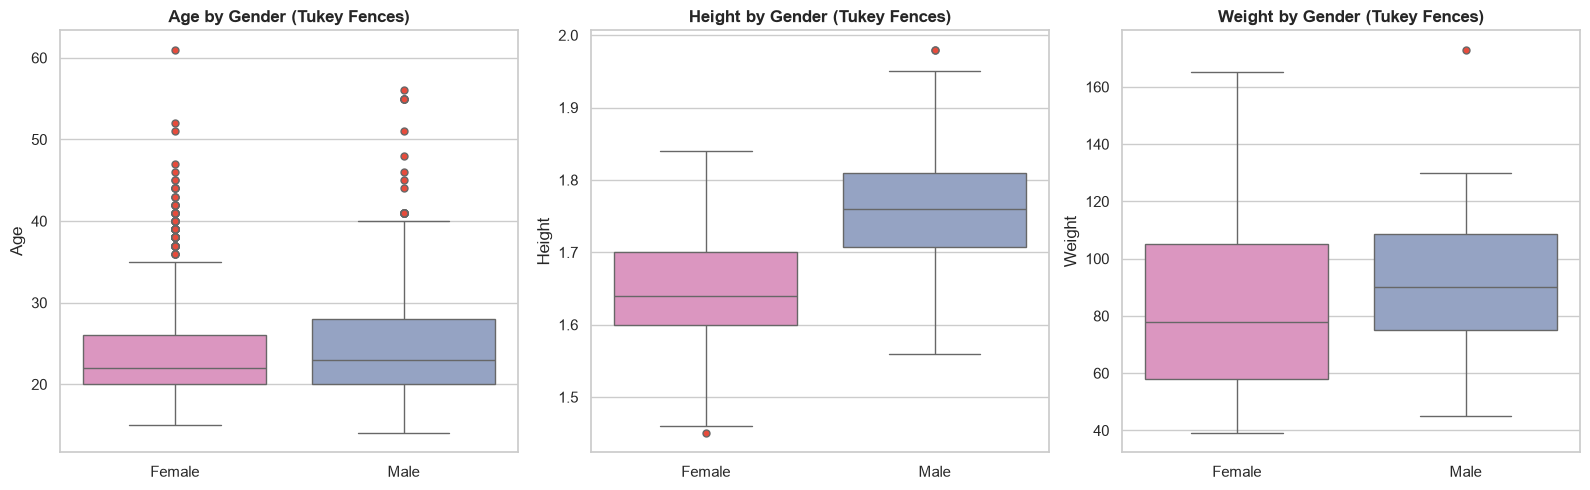

In [6]:
continuous_cols = ['Age', 'Height', 'Weight']
genders = df['Gender'].unique()

print("=== GENDER-DISAGGREGATED TUKEY OUTLIER ANALYSIS ===")

for col in continuous_cols:
    print(f"\n--- Feature: {col} ---")
    for gender in genders:
        sub_df = df[df['Gender'] == gender]
        q1 = sub_df[col].quantile(0.25)
        q3 = sub_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        outliers = sub_df[(sub_df[col] < lower_bound) | (sub_df[col] > upper_bound)]
        outlier_pct = (len(outliers) / len(sub_df)) * 100
        
        print(f"[{gender}] Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] -> Outliers: {len(outliers)} ({outlier_pct:.2f}%)")

# Visualize Gender-Disaggregated Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(
        data=df, 
        x='Gender', 
        y=col, 
        ax=axes[i], 
        palette={'Female': '#e78ac3', 'Male': '#8da0cb'},
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5)
    )
    axes[i].set_title(f'{col} by Gender (Tukey Fences)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../visuals/boxplots_for_outlier_inspection_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Observations from Gender-Disaggregated Outlier Inspection

* **Sex-Specific Threshold Alignment:** Calculating Tukey bounds by `Gender` prevents group-level distortion. The lower boundary for female height and the upper boundary for male weight now accurately reflect sex-specific physiological limits.
* **Persistent High-Weight Outliers:** Upper-bound outliers in `Weight` remain present across both male and female groups, corresponding strictly to severe obesity profiles (Obesity Type III) where extreme values reflect true clinical condition rather than erroneous data points.
* **Outlier Retention Strategy:** Since these intra-group extreme values represent valid, high-impact clinical records essential for downstream target classification across sexes, **all detected outliers will be retained in the dataset**.

## 3. Bivariate Relationship: Biometrics vs. Obesity Level (`NObeyesdad`)

We analyze how biometric distributions vary across different obesity categories to evaluate feature separation quality before downstream modeling.

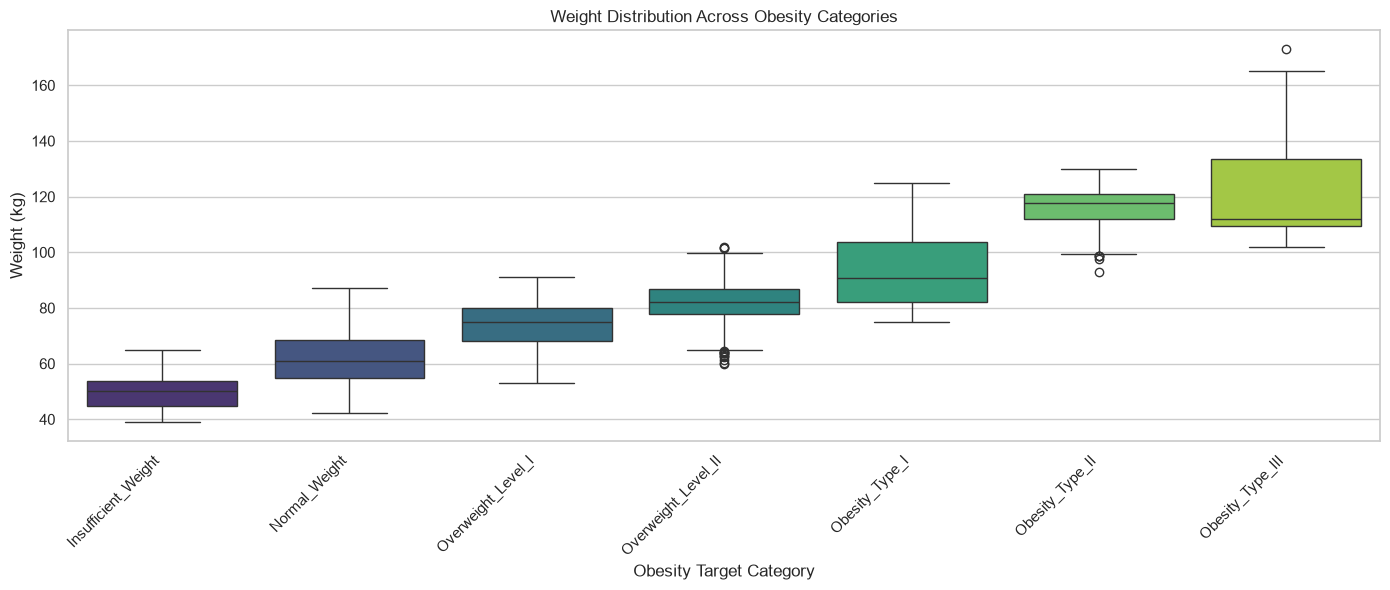

In [7]:
plt.figure(figsize=(14, 6))

# Order categories logically
obesity_order = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

sns.boxplot(
    data=df, 
    x='NObeyesdad', 
    y='Weight', 
    order=obesity_order, 
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Weight Distribution Across Obesity Categories')
plt.xlabel('Obesity Target Category')
plt.ylabel('Weight (kg)')
plt.tight_layout()
plt.savefig('../visuals/boxplots_for_obesity_categories.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Bivariate Analysis Insights: Weight vs. Obesity Category

* **Strong Feature Separability:** A linear, monotonic increase in median weight is observed across the ordered target categories (ranging from ~50 kg in `Insufficient_Weight` to >110 kg in `Obesity_Type_III`). This indicates `Weight` is a primary driver for target discrimination.
* **Variance & Asymmetry in Extreme Classes:** While intermediate categories (e.g., `Overweight_Level_II`) exhibit compact Interquartile Ranges (IQR), `Obesity_Type_III` displays high variance and right-skewness, reaching maximum values above 170 kg.
* **Outlier Contextualization:** Lower outliers in `Overweight_Level_II` (~60–65 kg) and `Obesity_Type_II` represent valid instances where individual height shifts the Body Mass Index (BMI) threshold, confirming these values are biological variations rather than entry errors.

#### 🚻 Target Separability Analysis: Weight vs. Obesity Category by Gender

While continuous distributions show global metric ranges, assessing how `Weight` relates to our target variable (`NObeyesdad`) across biological sexes is essential. 

We construct a gender-disaggregated boxplot to examine class separability, evaluate variance across obesity levels, and verify if weight thresholds exhibit sex-specific behavior across categories.

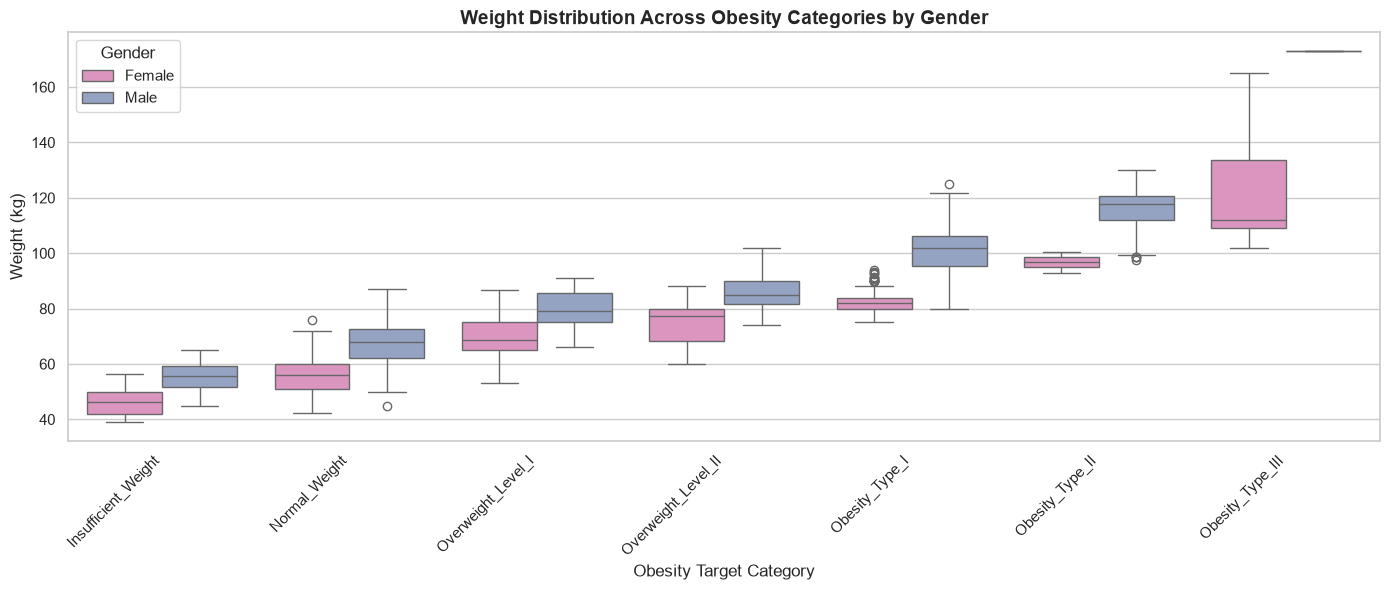

In [8]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df, 
    x='NObeyesdad', 
    y='Weight', 
    hue='Gender',
    order=obesity_order, 
    palette={'Female': '#e78ac3', 'Male': '#8da0cb'}
)

plt.xticks(rotation=45, ha='right')
plt.title('Weight Distribution Across Obesity Categories by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Target Category')
plt.ylabel('Weight (kg)')
plt.legend(title='Gender', frameon=True)
plt.tight_layout()
plt.savefig('../visuals/boxplots_for_obesity_categories_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Key Observations on Target Separability & Gender Trends

* **Sex-Specific Threshold Shift:** Across lower and intermediate classes (e.g., `Overweight_Level_I` & `II`), males consistently exhibit higher median weights than females within the same category. This stems from height differences required to hit equivalent BMI target ranges.
* **Class Dispersion & Convergence:** Lower variance is observed in intermediate categories, whereas extreme target classes like `Obesity_Type_III` display higher dispersion—particularly in females, where weight spans a wider range.
* **Feature Strategy Validation:** The distinct weight progression across categories validates using distance-based or tree-based algorithms for classification, while highlighting that `Gender` and `Height` must accompany `Weight` to resolve boundary overlaps between adjacent categories.

## 4. Key Findings & Preprocessing Strategy

1. **Distribution Integrity:** The post-cleaning continuous distributions reflect realistic domain bounds. Disaggregating by `Gender` revealed distinct physiological baseline shifts—most notably a bimodal distribution in `Height` and differing variance in `Weight`.
2. **Gender-Aware Outlier Retention:** Tukey's rule applied independently by gender confirmed that extreme values in `Age` and upper-bound `Weight` are non-erroneous biological variations. They directly align with severe obesity profiles (e.g., `Obesity_Type_III`) and will be fully retained to preserve critical classification signals.
3. **Target Separability & Sex-Specific Shifts:** `Weight` displays a strong monotonic relationship with `NObeyesdad`. Sex-specific shifts in weight thresholds across intermediate categories underscore the necessity of keeping `Gender` and incorporating height-adjusted metrics ($\text{BMI}$).

## 5. Multivariate Correlation Analysis & Gender Disaggregation

To evaluate how behavioral, dietary, and demographic features interact with body mass—and to identify potential multicollinearity—we construct a **Pearson Correlation Matrix**.

### Key Methodological Decisions:
1. **Feature Substitution:** `Weight` and `Height` are excluded and replaced by `BMI` ($\text{BMI} = \frac{\text{Weight}}{\text{Height}^2}$) to eliminate obvious structural multicollinearity while capturing the exact physical indicator defining `NObeyesdad`.
2. **Temporary Encoding:** Ordinal frequency and binary features are temporarily mapped to numeric scales solely for continuous correlation computation.
3. **Gender Disaggregation:** Separate matrices are computed for `Female` and `Male` sub-populations to identify sex-specific behavioral drivers of higher body mass.

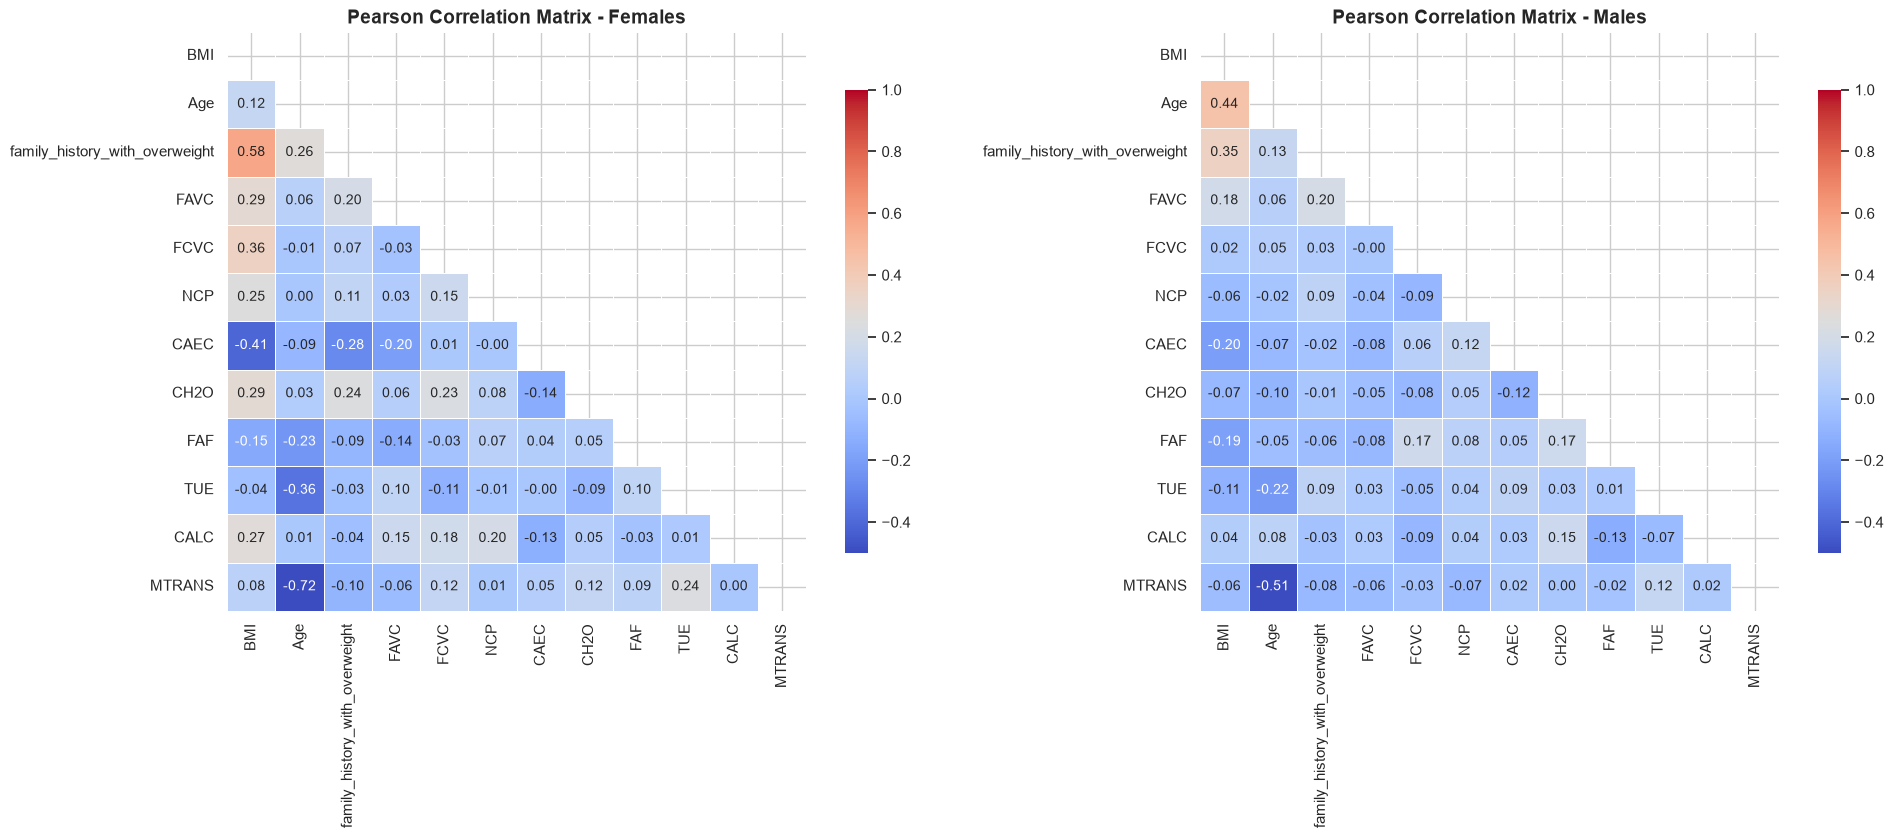

In [9]:
# 1. Feature Engineering: Calculate BMI (BMI)
df_corr = df.copy()
df_corr['BMI'] = df_corr['Weight'] / (df_corr['Height'] ** 2)

# 2. Temporary Binary & Ordinal Mappings for Pearson Analysis
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

freq_map = {'no': 1, 'Sometimes': 2, 'Frequently': 3, 'Always': 4}
df_corr['CAEC'] = df_corr['CAEC'].map(freq_map)
df_corr['CALC'] = df_corr['CALC'].map(freq_map)

mtrans_map = {'Automobile': 1, 'Motorbike': 2, 'Bike': 3, 'Public_Transportation': 4, 'Walking': 5}
df_corr['MTRANS'] = df_corr['MTRANS'].map(mtrans_map)

# 3. Define Analysis Subset (Excluding Height & Weight)
corr_features = [
    'BMI', 'Age', 'family_history_with_overweight', 
    'FAVC', 'FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'MTRANS'
]

# Split by Gender
df_female = df_corr[df_corr['Gender'] == 'Female'][corr_features]
df_male = df_corr[df_corr['Gender'] == 'Male'][corr_features]

# 4. Plot Side-by-Side Correlation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Mask for upper triangle to improve readability
mask = np.triu(np.ones_like(df_female.corr(), dtype=bool))

# Female Heatmap
sns.heatmap(
    df_female.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    vmin=-0.5, vmax=1, linewidths=0.5, square=True, cbar_kws={"shrink": .8}, ax=axes[0]
)
axes[0].set_title('Pearson Correlation Matrix - Females', fontsize=14, fontweight='bold')

# Male Heatmap
sns.heatmap(
    df_male.corr(), mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    vmin=-0.5, vmax=1, linewidths=0.5, square=True, cbar_kws={"shrink": .8}, ax=axes[1]
)
axes[1].set_title('Pearson Correlation Matrix - Males', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/heatmaps_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Key Findings from Gender-Disaggregated Correlation Analysis

* **Dominant Risk Driver (`family_history_with_overweight`):** Displays the strongest positive correlation with `BMI` across both genders, establishing family background as a primary baseline predictor for target elevation.
* **Dietary Patterns (`FAVC` & `CAEC`):** High-calorie food consumption (`FAVC`) and eating between meals (`CAEC`) show positive linear trends with `BMI`. However, the correlation magnitude differs across sexes, suggesting varying behavioural impact between male and female cohorts.
* **Physical Activity Mitigation (`FAF`):** Frequency of physical activity (`FAF`) displays a clearer negative correlation with `BMI` in male profiles compared to females, underscoring sex-specific lifestyle interactions.
* **Absence of Severe Multicollinearity:** Aside from predictable domain interactions, no behavioral feature pairs exceed $|r| > 0.8$, confirming that all selected features carry independent signal and can be safely passed to `05_feature_engineering_and_scaling.ipynb`.